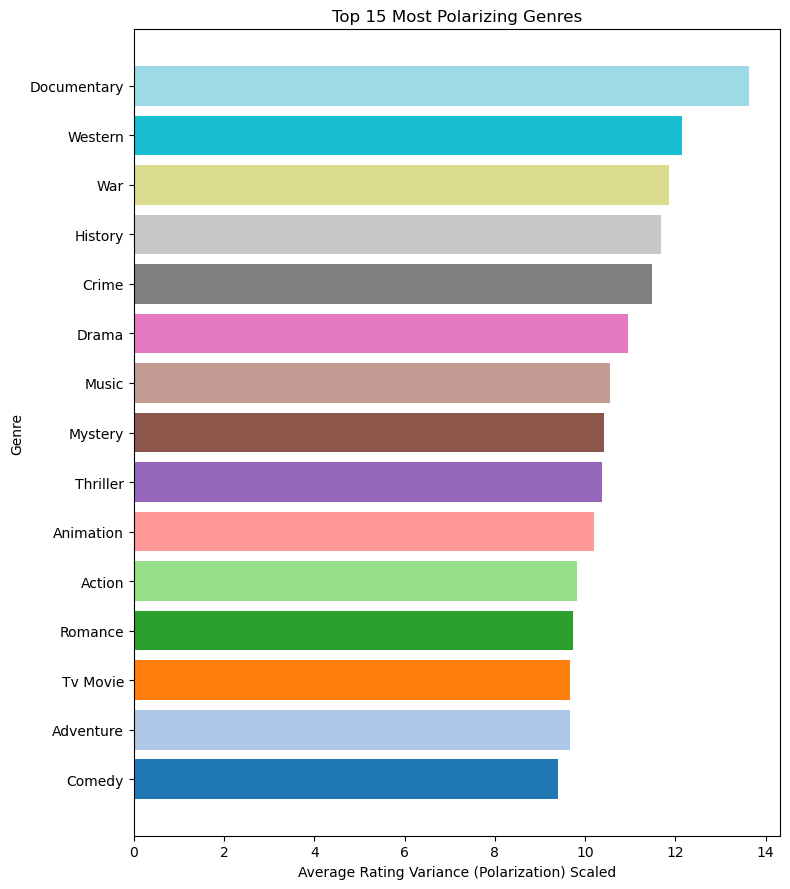

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

# Read data into notebook
df = pd.read_csv("Movie_Data_File.csv")

star_cols = [
    "½",
    "★",
    "★½",
    "★★",
    "★★½",
    "★★★",
    "★★★½",
    "★★★★",
    "★★★★½",
    "★★★★★"
]

# Remove rows without genre
df = df.dropna(subset=["Genres"])

# Genres are comma-separated so split and explode
df["Genres"] = df["Genres"].apply(ast.literal_eval)
df = df.explode("Genres")
# Need to clean genres formatting
df["Genres"] = (
    df["Genres"]
    .str.strip() # Remove leading/trailing spaces
    .str.title() # Standardize capitalization
)

# Calculate total ratings per film
df["Total_Ratings_Calc"] = df[star_cols].sum(axis=1)

# Convert star counts into proportions
for col in star_cols:
    df[col + "_prop"] = df[col] / df["Total_Ratings_Calc"]

prop_cols = [col + "_prop" for col in star_cols]

# Compute variance across rating proportions (polarization metric)
df["rating_variance"] = df[prop_cols].var(axis=1)

# Average polarization per genre
genre_polarization = (
    df.groupby("Genres")["rating_variance"]
    .mean()
    .sort_values(ascending=False)
)

# Show only top 15 most polarized genres for readability
top_n = 15
top_genres = genre_polarization.head(top_n)
top_genres_scaled = top_genres * 1000
sorted_genres = top_genres_scaled.sort_values()
colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_genres)))

plt.figure(figsize=(8, 9))
plt.barh(
    sorted_genres.index,
    sorted_genres.values,
    color=colors
)
plt.xlabel("Average Rating Variance (Polarization) Scaled")
plt.ylabel("Genre")
plt.title("Top 15 Most Polarizing Genres")
plt.tight_layout()
plt.show()